In [39]:
import h5py
import matplotlib.pyplot as plt
import os
import importlib
from pid_functions import *
import numpy as np
from scipy import signal
from scipy.io import savemat
import pandas as pd
import seaborn as sns
sns.set_context('poster')

In [41]:
def arrays_to_excel(arr1: np.ndarray, arr2: np.ndarray, filename: str,
                    col1_name: str = "Column1", col2_name: str = "Column2"):
    """
    Save two 1D numpy arrays as an Excel file with one column per array.

    Parameters
    ----------
    arr1 : np.ndarray
        First 1D array.
    arr2 : np.ndarray
        Second 1D array.
    filename : str
        Output Excel filename, e.g. "output.xlsx".
    col1_name : str
        Column name for the first array.
    col2_name : str
        Column name for the second array.
    """

    # Ensure 1D arrays
    arr1 = np.ravel(arr1)
    arr2 = np.ravel(arr2)

    if arr1.shape[0] != arr2.shape[0]:
        raise ValueError(f"Arrays must have the same length, got {len(arr1)} and {len(arr2)}")

    df = pd.DataFrame({
        col1_name: arr1,
        col2_name: arr2
    })

    with pd.ExcelWriter(
            "source_data_all_figs.xlsx",
            engine="openpyxl",
            mode="a",                 # append to existing file q
            if_sheet_exists="new"     # avoid overwriting an existing sheet
        ) as writer:
        df.to_excel(writer, sheet_name="Supp_Figure_1_A", index=False)

In [35]:
path = os.getcwd() + '/PID/20250828/'
filename = 'mb_5perc_94o_pmed_g5_0.h5'
filepath = path + filename
print(filepath)
dfile = h5py.File(filepath,'r')
print(list(dfile['measurement'].keys())[0]) #['measurement'].keys()
data = dfile['measurement/block_training/buffer'][:] #load data buffer to numpy arrray
stat = dfile['measurement/block_training/stat'][:] #load task statistics
side_stat = dfile['measurement/block_training/side_stat'][:]  #load task statistics with side information
settings = dfile['measurement/block_training/settings'].attrs

# Load raw data into numpy array
lick0 = 1
lick1 = 2
PID_index = 3 # index number for PID signal
cl_air = 6 + 4 #index number of clean air channel in h5file
odor_1 = 6 + 0 #index number of odor channel 1 in h5file
end_time = len(data) # in milisecond
delay_time = settings['delay'] #ms, delay time of the task
go_time = settings['go'] #ms, go time of the task
refract_time = settings['refract'] #ms, refraction period time of the task
pulse_time = 50
ntrials = np.argwhere(np.diff(data[:,cl_air]) == -94).shape[0]

PID_signal = data[0:end_time,PID_index]
filt_signal = bp_bessel(PID_signal-np.median(PID_signal))
odor_profile_1 = data[0:end_time,odor_1]

total_time = delay_time + go_time #ms, the total time that we are analyzing for each trial
onset = np.argwhere(np.diff(data[:,cl_air]) == -94).reshape(ntrials,1) #find out hte onset of each trial
interval = np.arange(total_time).reshape(1,total_time) #define a interval to extract for each trial
refract_interval = np.arange(refract_time)[::-1].reshape(1,refract_time) # define a interval for pretrial, flipped
trial_inds = onset + interval #get the indices for all the wanted data for all trials
pre_inds = onset - refract_interval #get the indices for all the wanted data in all pre-trials

# get all the trial informations
trial_odor = data[:,odor_1][trial_inds[:-1,:]]
PID = PID_signal[trial_inds[:-1,:]]
PID_filt = filt_signal[trial_inds[:-1,:]]

/Users/boero/OEA_Data_Analysis/PID/20250828/mb_5perc_94o_pmed_g5_0.h5
block_training


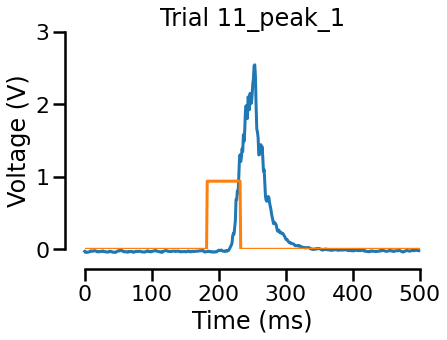

In [36]:
trial=11
plt.plot(PID[trial,750:1250], clip_on=False)
plt.plot(trial_odor[trial,750:1250]/100)
plt.xlim(0,500)
plt.ylim(0,3)
plt.title('Trial '+str(trial)+'_peak_1')


plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
sns.despine(offset=20)

In [42]:
PID_sp_mb = PID[11,750:1250] 
odor_sp_mb = trial_odor[11,750:1250]/100
arrays_to_excel(PID_sp_mb, odor_sp_mb, "source_data_all_figs.xlsx",
                    col1_name="PID_signal_sp_mb", col2_name="Odor_signal_sp_mb")

In [43]:
path = os.getcwd() + '/PID/20250828/'
filename = 'mb_5perc_94o_pmed_g5_only_high_0.h5'
filepath = path + filename
print(filepath)
dfile = h5py.File(filepath,'r')
print(list(dfile['measurement'].keys())[0]) #['measurement'].keys()
data = dfile['measurement/block_training/buffer'][:] #load data buffer to numpy arrray
stat = dfile['measurement/block_training/stat'][:] #load task statistics
side_stat = dfile['measurement/block_training/side_stat'][:]  #load task statistics with side information
settings = dfile['measurement/block_training/settings'].attrs

# Load raw data into numpy array
lick0 = 1
lick1 = 2
PID_index = 3 # index number for PID signal
cl_air = 6 + 4 #index number of clean air channel in h5file
odor_1 = 6 + 0 #index number of odor channel 1 in h5file
end_time = len(data) # in milisecond
delay_time = settings['delay'] #ms, delay time of the task
go_time = settings['go'] #ms, go time of the task
refract_time = settings['refract'] #ms, refraction period time of the task
pulse_time = 50
ntrials = np.argwhere(np.diff(data[:,cl_air]) == -94).shape[0]

PID_signal = data[0:end_time,PID_index]
filt_signal = bp_filter(PID_signal-np.median(PID_signal))
odor_profile_1 = data[0:end_time,odor_1]

total_time = delay_time + go_time #ms, the total time that we are analyzing for each trial
onset = np.argwhere(np.diff(data[:,cl_air]) == -94).reshape(ntrials,1) #find out hte onset of each trial
interval = np.arange(total_time).reshape(1,total_time) #define a interval to extract for each trial
refract_interval = np.arange(refract_time)[::-1].reshape(1,refract_time) # define a interval for pretrial, flipped
trial_inds = onset + interval #get the indices for all the wanted data for all trials
pre_inds = onset - refract_interval #get the indices for all the wanted data in all pre-trials

# get all the trial informations
trial_odor = data[:,odor_1][trial_inds[:-1,:]]
PID = PID_signal[trial_inds[:-1,:]]
PID_filt = filt_signal[trial_inds[:-1,:]]

/Users/boero/OEA_Data_Analysis/PID/20250828/mb_5perc_94o_pmed_g5_only_high_0.h5
block_training


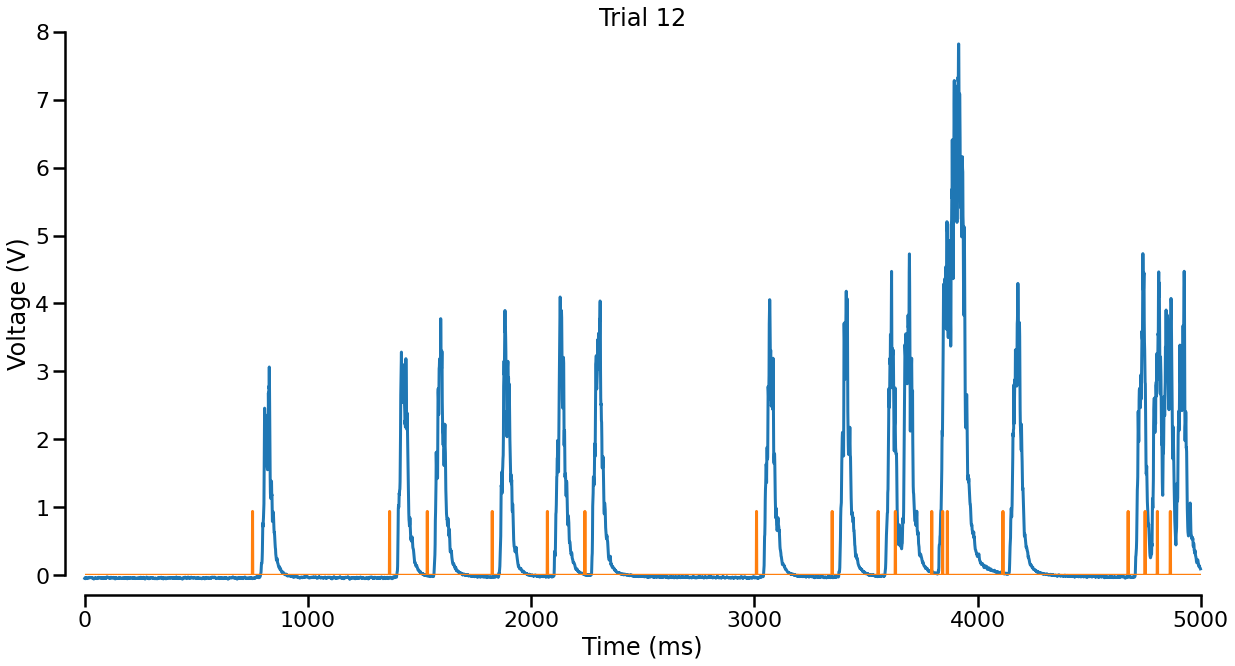

In [44]:
trial=12
plt.figure(figsize=(20,10))
plt.plot(PID[trial,:5000], clip_on=False)
#plt.plot(trial_odor[trial,:5000]/100)
plt.plot(np.diff(trial_odor[trial, :5000])/100)
plt.xlim(0,5000)
plt.ylim(0,8)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('Trial '+str(trial))
sns.despine(offset=20)

In [47]:
PID_mp_mb = PID[12,:5000] 
odor_mp_mb = (trial_odor[trial, :5000])/100
arrays_to_excel(PID_mp_mb, odor_mp_mb, "source_data_all_figs.xlsx",
                    col1_name="PID_signal_mp_mb", col2_name="Odor_mp_mb")

In [48]:
path = os.getcwd() + '/PID/20250828/'
filename = 'ev_5perc_94o_pmed_g5_1.h5'
filepath = path + filename
print(filepath)
dfile = h5py.File(filepath,'r')
print(list(dfile['measurement'].keys())[0]) #['measurement'].keys()
data_ev = dfile['measurement/block_training/buffer'][:] #load data buffer to numpy arrray
stat = dfile['measurement/block_training/stat'][:] #load task statistics
side_stat = dfile['measurement/block_training/side_stat'][:]  #load task statistics with side information
settings = dfile['measurement/block_training/settings'].attrs

# Load raw data into numpy array
lick0 = 1
lick1 = 2
PID_index = 3 # index number for PID signal
cl_air = 6 + 4 #index number of clean air channel in h5file
odor_1 = 6 + 3 #index number of odor channel 1 in h5file
end_time_ev = len(data_ev) # in milisecond
delay_time_ev = settings['delay'] #ms, delay time of the task

go_time_ev = settings['go'] #ms, go time of the task
refract_time_ev = settings['refract'] #ms, refraction period time of the task
pulse_time = 50
ntrials_ev = np.argwhere(np.diff(data_ev[:,cl_air]) == -94).shape[0]
print(delay_time_ev, go_time_ev)
print(ntrials_ev)

PID_signal_ev = data_ev[0:end_time_ev,PID_index]-np.median(data_ev[0:end_time_ev,PID_index])
#filt_signal = pid_functions.bp_filter(PID_signal-np.median(PID_signal))
#odor_profile_1 = data[0:end_time,odor_1]

total_time_ev = delay_time_ev + go_time_ev #ms, the total time that we are analyzing for each trial
onset_ev = np.argwhere(np.diff(data_ev[:,cl_air]) == -94).reshape(ntrials_ev,1) #find out hte onset of each trial
interval_ev = np.arange(total_time_ev).reshape(1,total_time_ev) #define a interval to extract for each trial
refract_interval_ev = np.arange(refract_time)[::-1].reshape(1,refract_time) # define a interval for pretrial, flipped
trial_inds_ev = onset_ev + interval_ev #get the indices for all the wanted data for all trials
pre_inds_ev = onset_ev - refract_interval_ev #get the indices for all the wanted data in all pre-trials

# get all the trial informations
trial_odor_ev = data_ev[:,odor_1][trial_inds_ev[:-1,:]]
PID_ev = PID_signal_ev[trial_inds_ev[:-1,:]]

/Users/boero/OEA_Data_Analysis/PID/20250828/ev_5perc_94o_pmed_g5_1.h5
block_training
5000 1500
41


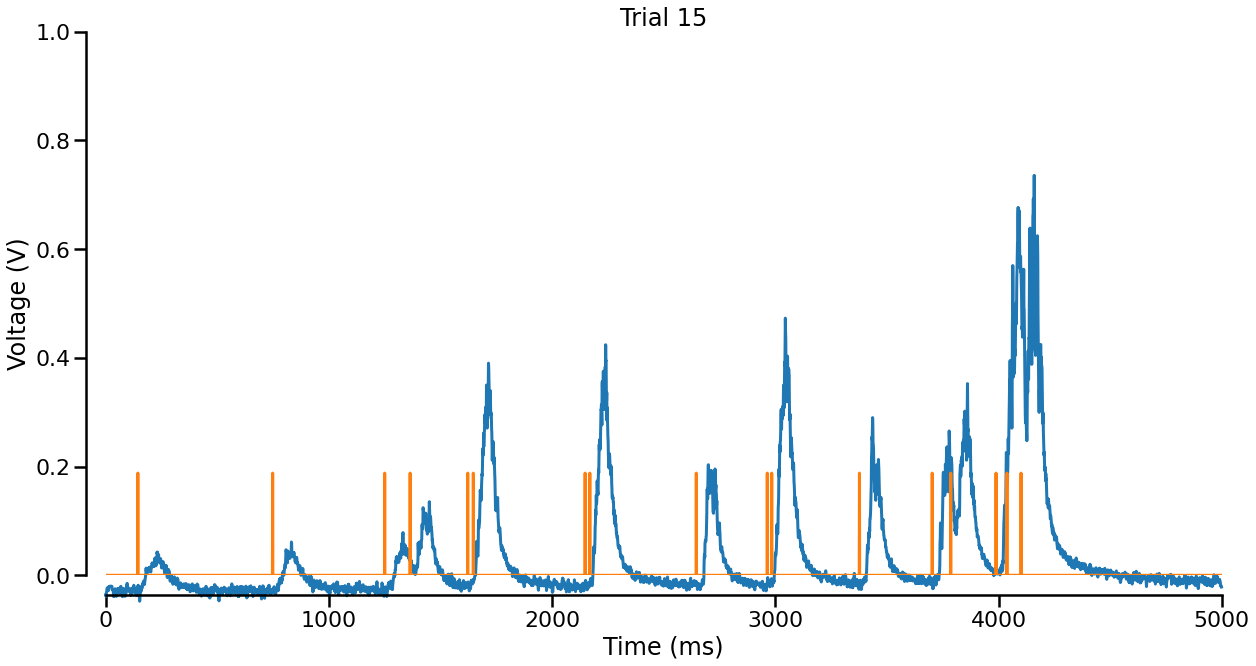

In [49]:
trial=15

plt.figure(figsize=(20,10))

plt.plot(PID_ev[trial,:5000], clip_on=False)
#plt.plot(trial_odor_ev[trial,:5000]/100)
plt.plot(np.diff(trial_odor_ev[trial, :5000])/500)
plt.xlim(0,5000)
plt.ylim(0,1)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('Trial '+str(trial))
sns.despine(offset=20)

In [50]:
PID_mp_ev = PID_ev[15,:5000] 
odor_mp_ev = (trial_odor_ev[15, :5000])/100
arrays_to_excel(PID_mp_ev, odor_mp_ev, "source_data_all_figs.xlsx",
                    col1_name="PID_signal_mp_ev", col2_name="Odor_mp_ev")

In [51]:
path = os.getcwd() + '/PID/20180426/'
filename = 'odor_50ms_1.h5'
filepath = path + filename
print(filepath)
dfile = h5py.File(filepath,'r')
print(list(dfile['measurement'].keys())[0]) #['measurement'].keys()
data = dfile['measurement/block_training/buffer'][:] #load data buffer to numpy arrray
stat = dfile['measurement/block_training/stat'][:] #load task statistics
side_stat = dfile['measurement/block_training/side_stat'][:]  #load task statistics with side information
settings = dfile['measurement/block_training/settings'].attrs

# Load raw data into numpy array
#breath = 0
lick0 = 1
lick1 = 2
PID_index = 0 # index number for PID signal
cl_air = 6 + 0 #index number of clean air channel in h5file
#odor_0 = 6 + 0
odor_1 = 6 + 3 #index number of odor channel 1 in h5file
#odor_2 = 6 + settings['channel2'] #index number of odor channel 2 in h5file
end_time = len(data) # in milisecond
delay_time = settings['delay'] #ms, delay time of the task
go_time = settings['go'] #ms, go time of the task
refract_time = settings['refract'] #ms, refraction period time of the task
pulse_time = 50
ntrials = np.argwhere(np.diff(data[:,cl_air]) == -88).shape[0]

PID_signal = data[0:end_time,PID_index]
filt_signal = bp_bessel(PID_signal-np.median(PID_signal))
odor_profile_1 = data[0:end_time,odor_1]

print(ntrials)

total_time = delay_time + go_time #ms, the total time that we are analyzing for each trial
print(total_time)
onset = np.argwhere(np.diff(data[:,cl_air]) == -88).reshape(ntrials,1) #find out hte onset of each trial
interval = np.arange(total_time).reshape(1,total_time) #define a interval to extract for each trial
refract_interval = np.arange(refract_time)[::-1].reshape(1,refract_time) # define a interval for pretrial, flipped
trial_inds = onset + interval #get the indices for all the wanted data for all trials
pre_inds = onset - refract_interval #get the indices for all the wanted data in all pre-trials

# get all the trial informations
trial_odor = data[:,odor_1][trial_inds[:-1,:]]
PID = PID_signal[trial_inds[:-1,:]]
PID_filt = filt_signal[trial_inds[:-1,:]]

/Users/boero/OEA_Data_Analysis/PID/20180426/odor_50ms_1.h5
block_training
7
5500


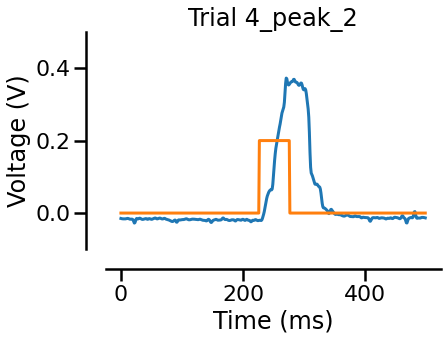

In [52]:
trial=4
plt.plot(PID_filt[trial,1500:2000])
plt.plot(trial_odor[trial,1500:2000]/500)
#plt.xlim(1300,1900)
plt.ylim(-0.1,0.5)
plt.title('Trial '+str(trial)+'_peak_2')


plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
sns.despine(offset=20)

In [53]:
PID_sp_ev = PID_filt[4,1500:2000] 
odor_sp_ev = (trial_odor[4, 1500:2000])/500
arrays_to_excel(PID_sp_ev, odor_sp_ev, "source_data_all_figs.xlsx",
                    col1_name="PID_signal_sp_ev", col2_name="Odor_sp_ev")